# Лабораторная работа №2
# «Виртуальный датчик для контроля процесса обжига в печи»

---

# 1. Постановка задачи

## Описание задачи

В рамках лабораторной работы требуется разработать виртуальный датчик для прогнозирования концентрации выходного продукта процесса обжига в промышленной печи.

Проблема заключается в том, что лабораторные измерения целевого показателя поступают с задержкой 10–15 минут и выполняются нерегулярно. Из-за этого оператор не может оперативно реагировать на изменения технологического процесса.

Цель работы — построить модель машинного обучения, способную прогнозировать значение концентрации продукта в текущий момент времени на основе телеметрических данных.


In [11]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.inspection import permutation_importance


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

import statsmodels.api as sm


from time import perf_counter


In [12]:
DATA_TRAIN_PATH = "data_train.csv"
TARGET_TRAIN_PATH = "target_train.csv"
DATA_TEST_PATH = "data_test_small.csv"
TARGET_TEST_PATH = "target_test_small.csv"

data_train = pd.read_csv(DATA_TRAIN_PATH, parse_dates=["datetime"])
target_train = pd.read_csv(TARGET_TRAIN_PATH, parse_dates=["Дата"]).rename(columns={"Дата": "datetime"})

data_test = pd.read_csv(DATA_TEST_PATH, parse_dates=["datetime"])
target_test = pd.read_csv(TARGET_TEST_PATH, parse_dates=["Дата"]).rename(columns={"Дата": "datetime"})

# Разведочный анализ данных (EDA)

In [13]:
# ============================================================
# Первичный анализ временной структуры и качества данных
# ============================================================

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["lines.linewidth"] = 1.8


# ------------------------------------------------------------
# Функция диагностики временного ряда
# ------------------------------------------------------------

def describe_timeframe(df, time_col="datetime"):

    diffs = (
        df[time_col]
        .sort_values()
        .diff()
        .dropna()
    )

    return pd.Series({
        "start_time": df[time_col].min(),
        "end_time": df[time_col].max(),
        "rows_count": len(df),
        "median_step_min": diffs.median() / pd.Timedelta(minutes=1) if len(diffs) else np.nan,
        "max_gap_min": diffs.max() / pd.Timedelta(minutes=1) if len(diffs) else np.nan,
        "duplicate_timestamps": int(df[time_col].duplicated().sum())
    })


# ------------------------------------------------------------
# Сводная таблица по временной структуре
# ------------------------------------------------------------

time_summary = pd.concat(
    {
        "telemetry_train": describe_timeframe(data_train),
        "target_train": describe_timeframe(target_train),
        "telemetry_test": describe_timeframe(data_test),
        "target_test": describe_timeframe(target_test),
    },
    axis=1
)

display(time_summary)

,telemetry_train,target_train,telemetry_test,target_test
start_time,2019-03-01 00:01:00,2019-03-13 17:00:00,2019-10-07 19:59:00,2019-10-07 23:00:00
end_time,2019-10-07 19:58:00,2019-10-07 21:00:00,2019-11-04 10:25:00,2019-11-04 09:00:00
rows_count,319546,1773,39943,318
median_step_min,1.0,120.0,1.0,120.0
max_gap_min,1.0,26430.0,1.0,1080.0
duplicate_timestamps,1548,0,196,0


Первичная диагностика показывает, что телеметрические данные
представляют собой почти непрерывный минутный временной ряд.

Лабораторные измерения, напротив, поступают значительно реже
и обладают нерегулярной временной структурой.

In [14]:
# ============================================================
# Проверка и обработка дубликатов timestamp
# ============================================================

def aggregate_duplicates(df):

    numeric_cols = [c for c in df.columns if c != "datetime"]

    return (
        df
        .groupby("datetime", as_index=False)[numeric_cols]
        .mean()
    )


print("Количество дубликатов ДО обработки:")
print("train:", data_train["datetime"].duplicated().sum())
print("test :", data_test["datetime"].duplicated().sum())


data_train = aggregate_duplicates(data_train)
data_test = aggregate_duplicates(data_test)


print("\nКоличество дубликатов ПОСЛЕ обработки:")
print("train:", data_train["datetime"].duplicated().sum())
print("test :", data_test["datetime"].duplicated().sum())

Количество дубликатов ДО обработки:
train: 1548
test : 196

Количество дубликатов ПОСЛЕ обработки:
train: 0
test : 0


Наличие повторяющихся timestamp может быть связано
с особенностями промышленной системы логирования
или повторной передачей пакетов телеметрии.

Для восстановления корректного временного ряда
дубликаты были агрегированы по среднему значению.

In [15]:
# ============================================================
# Анализ пропусков
# ============================================================

telemetry_cols = [
    c for c in data_train.columns
    if c.startswith("telemetry_")
]

missing_ratio = (
    data_train[telemetry_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

display(
    missing_ratio.to_frame("missing_ratio")
)


# ------------------------------------------------------------
# Разделение каналов на плотные и разреженные
# ------------------------------------------------------------

dense_cols = [
    c for c in telemetry_cols
    if missing_ratio[c] < 0.1
]

sparse_cols = [
    c for c in telemetry_cols
    if missing_ratio[c] >= 0.1
]

print("Плотные каналы:")
print(dense_cols)

print("\nРазреженные каналы:")
print(sparse_cols)

,missing_ratio
telemetry_12,0.993406
telemetry_13,0.993406
telemetry_14,0.993406
telemetry_15,0.993406
telemetry_4,0.000418
telemetry_0,0.000053
telemetry_5,0.000053
telemetry_1,0.000050
telemetry_7,0.000050
telemetry_6,0.000050


Плотные каналы:
['telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11']

Разреженные каналы:
['telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']


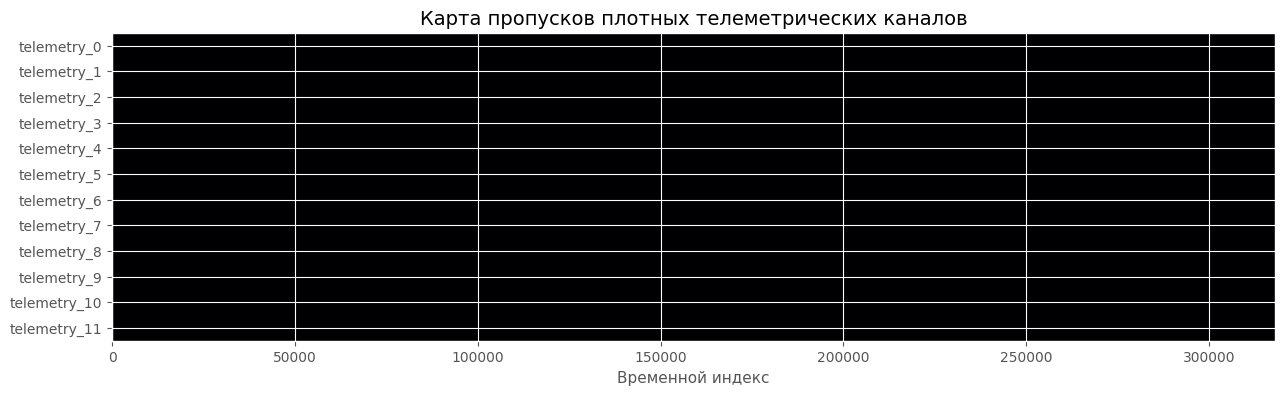

In [16]:
# ============================================================
# Визуализация пропусков
# ============================================================

fig, ax = plt.subplots(figsize=(15, 4))

ax.imshow(
    data_train[dense_cols].isna().T,
    aspect="auto",
    interpolation="nearest",
    cmap="magma"
)

ax.set_yticks(range(len(dense_cols)))
ax.set_yticklabels(dense_cols)

ax.set_title("Карта пропусков плотных телеметрических каналов")
ax.set_xlabel("Временной индекс")

plt.show()

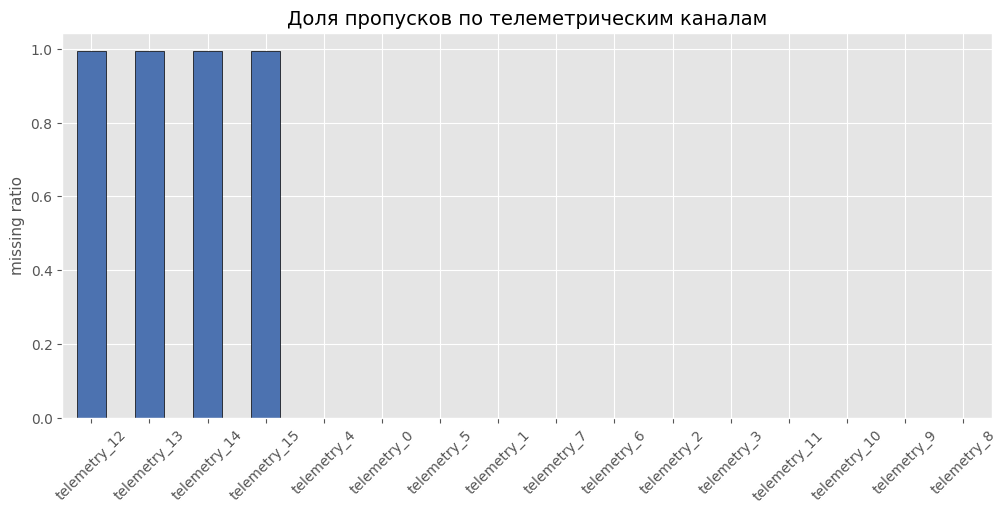

In [17]:
# ============================================================
# Доля пропусков по каналам
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

missing_ratio.plot(
    kind="bar",
    color="#4C72B0",
    edgecolor="black",
    ax=ax
)

ax.set_title("Доля пропусков по телеметрическим каналам")
ax.set_ylabel("missing ratio")

plt.xticks(rotation=45)
plt.show()

Большинство телеметрических каналов содержат минимальное
количество пропусков и могут рассматриваться как плотные.

Каналы telemetry_12–telemetry_15 являются крайне разреженными
и требуют отдельной стратегии обработки.

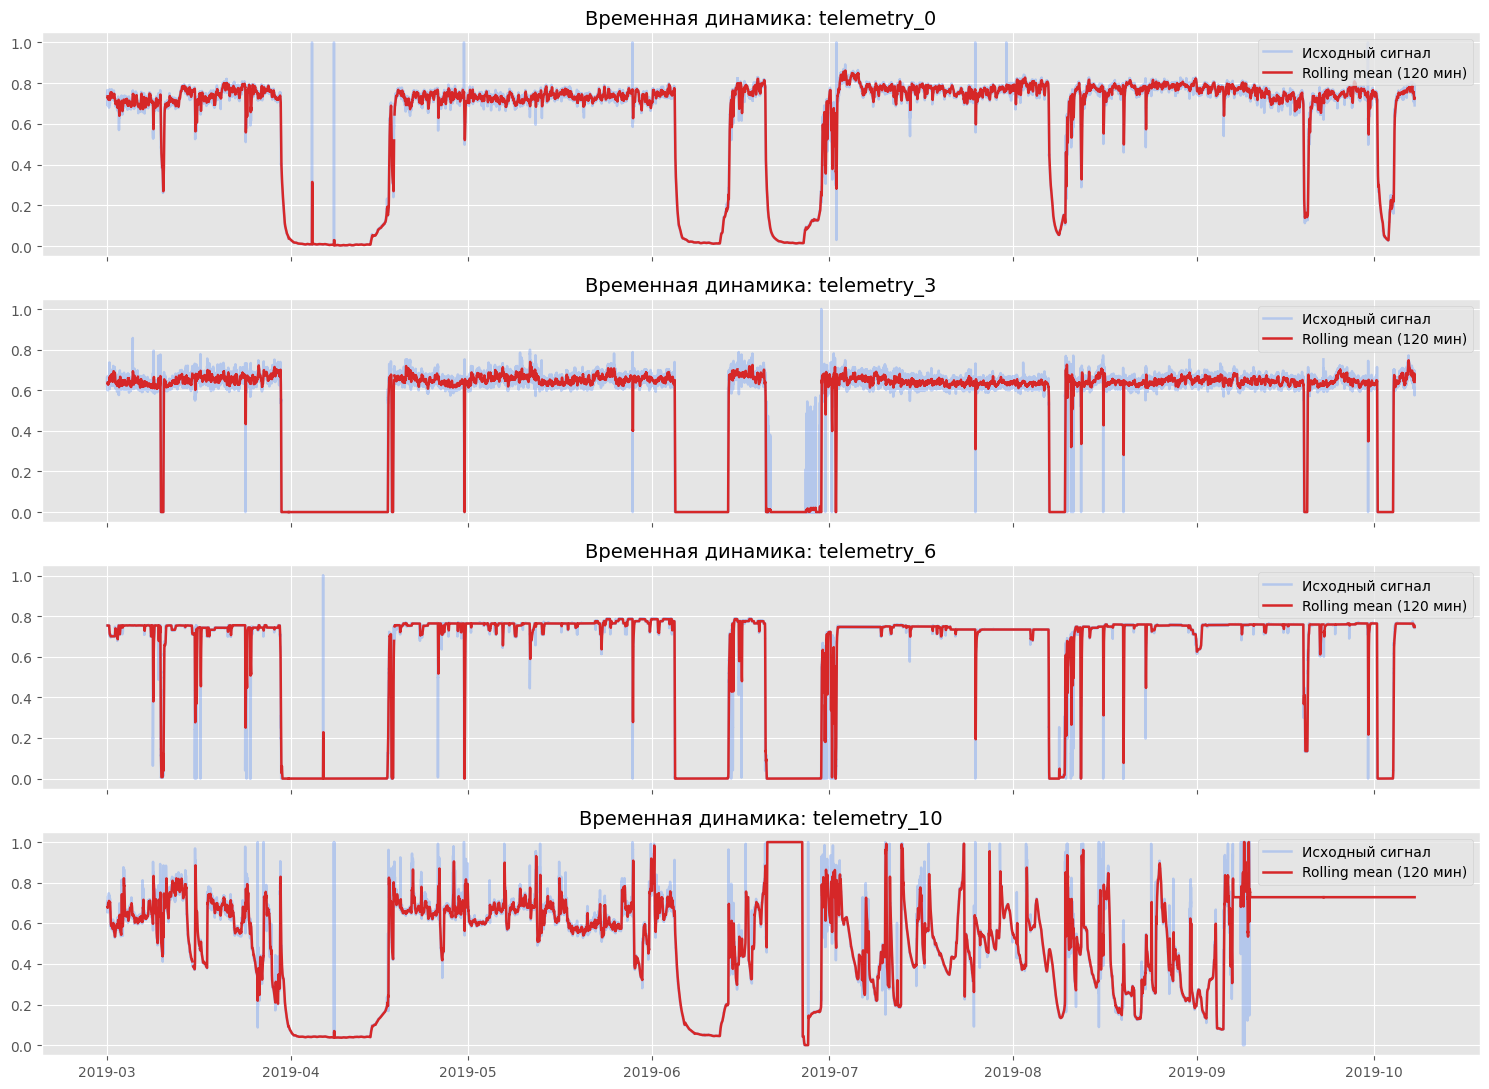

In [18]:
# ============================================================
# Анализ телеметрии во времени
# ============================================================

sample_features = [
    "telemetry_0",
    "telemetry_3",
    "telemetry_6",
    "telemetry_10"
]

fig, axes = plt.subplots(
    len(sample_features),
    1,
    figsize=(15, 11),
    sharex=True
)

for ax, col in zip(axes, sample_features):

    temp = data_train[["datetime", col]].copy()

    rolling = (
        temp[col]
        .rolling(120)
        .mean()
    )

    ax.plot(
        temp["datetime"],
        temp[col],
        alpha=0.35,
        color="#5B8FF9",
        label="Исходный сигнал"
    )

    ax.plot(
        temp["datetime"],
        rolling,
        color="#D62728",
        label="Rolling mean (120 мин)"
    )

    ax.set_title(f"Временная динамика: {col}")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

Телеметрические признаки обладают выраженной временной
динамикой и локальными колебаниями.

Сглаженные ряды показывают наличие инерционности процесса,
что характерно для непрерывных промышленных систем.

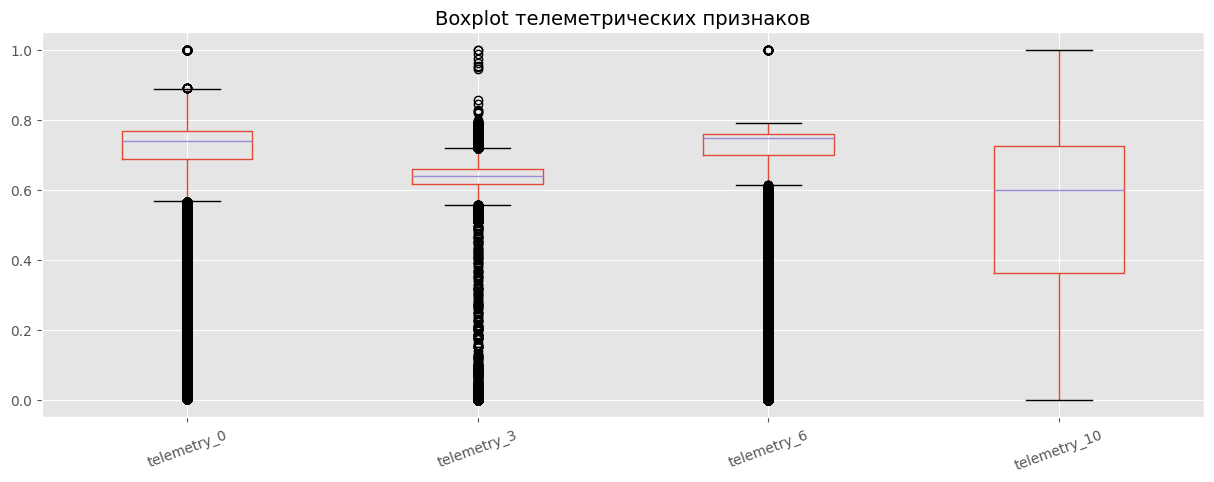

In [19]:
# ============================================================
# Анализ выбросов
# ============================================================

fig, ax = plt.subplots(figsize=(15, 5))

data_train[sample_features].boxplot(ax=ax)

ax.set_title("Boxplot телеметрических признаков")

plt.xticks(rotation=20)
plt.show()

Для части каналов наблюдаются выбросы и широкие диапазоны значений.

С инженерной точки зрения такие наблюдения могут соответствовать
изменениям технологического режима либо нештатным ситуациям.

Удаление выбросов на данном этапе не выполнялось,
поскольку они могут содержать полезную информацию
о поведении процесса обжига.

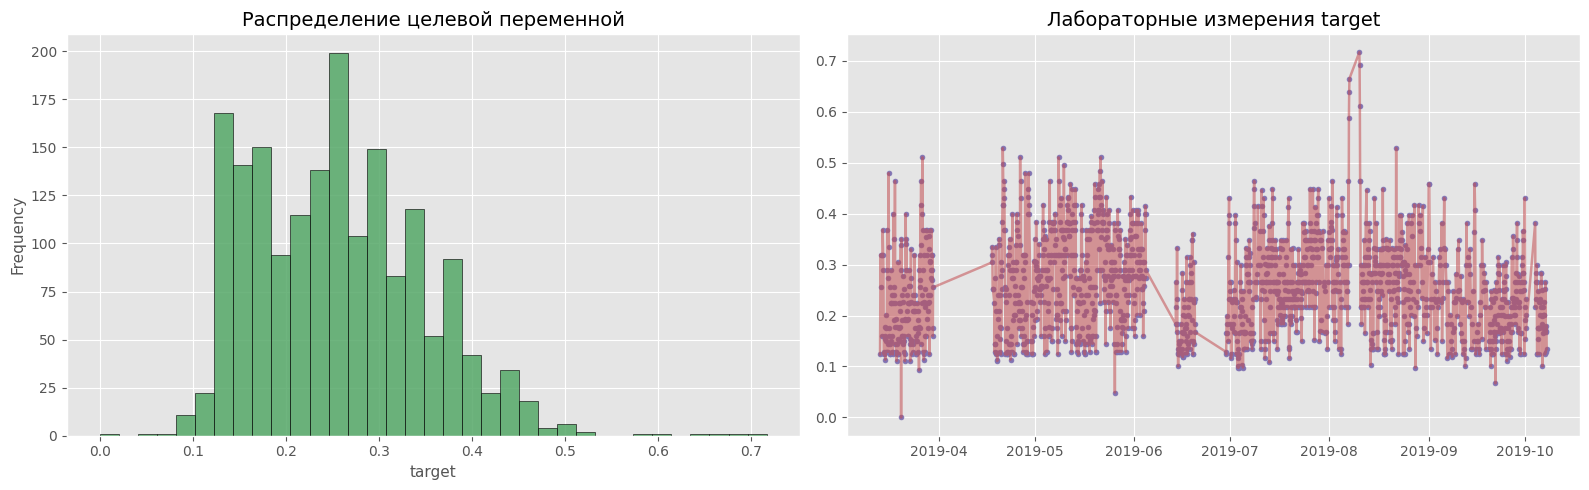

In [20]:
# ============================================================
# Анализ целевой переменной
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# ------------------------------------------------------------
# Распределение target
# ------------------------------------------------------------

target_train["target"].plot(
    kind="hist",
    bins=35,
    color="#55A868",
    edgecolor="black",
    alpha=0.85,
    ax=axes[0]
)

axes[0].set_title("Распределение целевой переменной")
axes[0].set_xlabel("target")


# ------------------------------------------------------------
# Динамика target во времени
# ------------------------------------------------------------

axes[1].plot(
    target_train["datetime"],
    target_train["target"],
    color="#C44E52",
    alpha=0.55
)

axes[1].scatter(
    target_train["datetime"],
    target_train["target"],
    s=12,
    color="#8172B2"
)

axes[1].set_title("Лабораторные измерения target")

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# Анализ интервалов между лабораторными измерениями
# ============================================================

target_train = target_train.sort_values("datetime").copy()

target_train["gap_min"] = (
    target_train["datetime"]
    .diff()
    .dt.total_seconds() / 60
)

display(
    target_train["gap_min"]
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
)

,gap_min
count,1772.000000
mean,169.164786
std,784.088290
min,60.000000
50%,120.000000
90%,240.000000
95%,240.000000
99%,240.000000
max,26430.000000


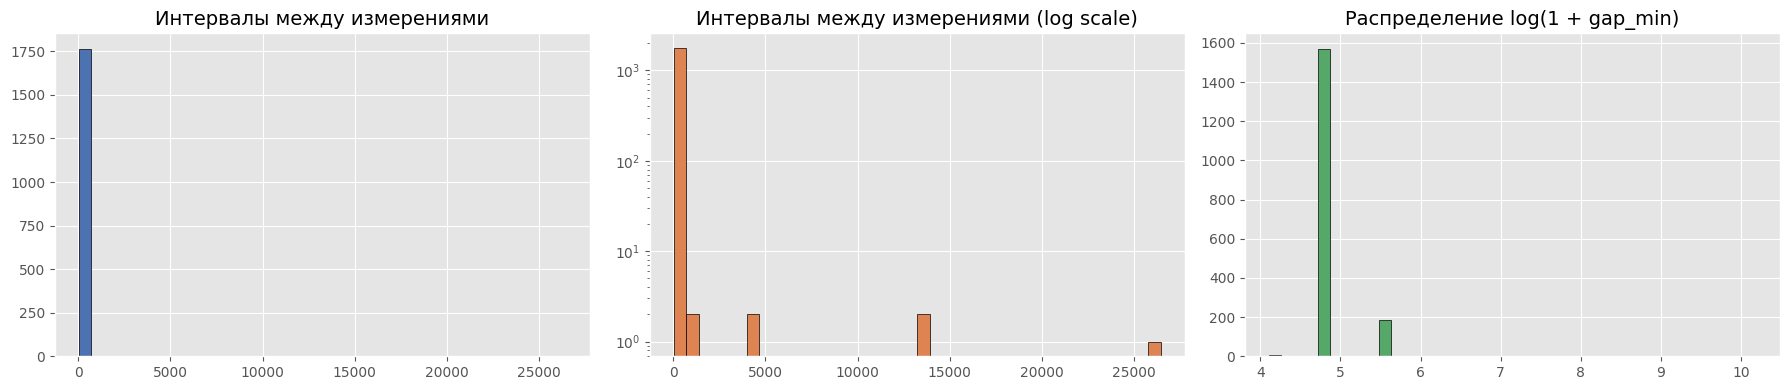

In [22]:
# ============================================================
# Визуализация интервалов между измерениями
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4))


# ------------------------------------------------------------
# Обычная гистограмма
# ------------------------------------------------------------

target_train["gap_min"].dropna().hist(
    bins=40,
    color="#4C72B0",
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Интервалы между измерениями")


# ------------------------------------------------------------
# Логарифмическая шкала
# ------------------------------------------------------------

target_train["gap_min"].dropna().hist(
    bins=40,
    color="#DD8452",
    edgecolor="black",
    ax=axes[1]
)

axes[1].set_yscale("log")
axes[1].set_title("Интервалы между измерениями (log scale)")


# ------------------------------------------------------------
# log1p распределение
# ------------------------------------------------------------

np.log1p(
    target_train["gap_min"].dropna()
).hist(
    bins=40,
    color="#55A868",
    edgecolor="black",
    ax=axes[2]
)

axes[2].set_title("Распределение log(1 + gap_min)")

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# Синхронизация лабораторных измерений
# ============================================================

def add_process_time(target_df, delay_minutes=12):

    out = target_df.copy()

    out["process_time"] = (
        out["datetime"]
        - pd.to_timedelta(delay_minutes, unit="m")
    )

    return out


target_train = add_process_time(target_train)

target_train.head()

,datetime,target,gap_min,process_time
0,2019-03-13 17:00:00,0.123711,NaN,2019-03-13 16:48:00
1,2019-03-13 21:00:00,0.319588,240.0,2019-03-13 20:48:00
2,2019-03-14 01:00:00,0.255155,240.0,2019-03-14 00:48:00
3,2019-03-14 05:00:00,0.319588,240.0,2019-03-14 04:48:00
4,2019-03-14 09:00:00,0.159794,240.0,2019-03-14 08:48:00


In [24]:
# ============================================================
# Корреляционный анализ лагов
# ============================================================

def lag_correlation_scan(
    data_df,
    target_df,
    feature_cols,
    max_lag=60
):

    rows = []

    data_indexed = data_df.set_index("datetime")

    for col in feature_cols:

        series = data_indexed[col]

        for lag in range(max_lag + 1):

            shifted_values = series.reindex(
                target_df["process_time"]
                - pd.to_timedelta(lag, unit="m")
            ).values

            corr = pd.Series(shifted_values).corr(target_df["target"])

            rows.append({
                "feature": col,
                "lag_min": lag,
                "corr": corr,
                "abs_corr": abs(corr) if pd.notna(corr) else np.nan
            })

    return pd.DataFrame(rows)


lag_corr = lag_correlation_scan(
    data_train,
    target_train,
    dense_cols,
    max_lag=60
)

lag_corr.head()

,feature,lag_min,corr,abs_corr
0,telemetry_0,0,-0.180212,0.180212
1,telemetry_0,1,-0.179402,0.179402
2,telemetry_0,2,-0.178375,0.178375
3,telemetry_0,3,-0.177327,0.177327
4,telemetry_0,4,-0.176569,0.176569


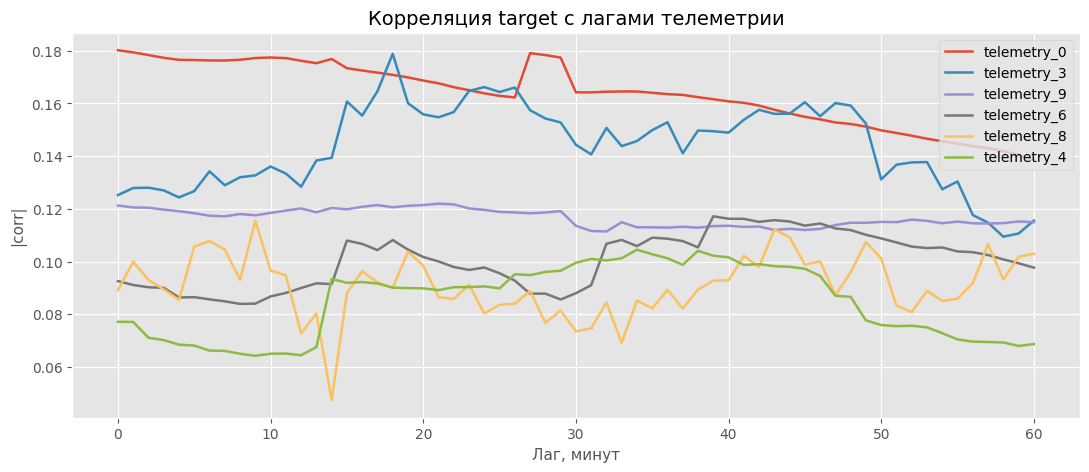

In [25]:
# ============================================================
# Наиболее информативные признаки
# ============================================================

top_features = (
    lag_corr
    .groupby("feature")["abs_corr"]
    .max()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(13, 5))

for feature in top_features:

    part = lag_corr[
        lag_corr["feature"] == feature
    ]

    ax.plot(
        part["lag_min"],
        part["abs_corr"],
        label=feature
    )

ax.set_title("Корреляция target с лагами телеметрии")
ax.set_xlabel("Лаг, минут")
ax.set_ylabel("|corr|")

ax.legend()

plt.show()

## Аналитический вывод по разведочному анализу данных

В ходе первичного анализа была исследована временная структура телеметрических и лабораторных данных.

Телеметрия представляет собой практически непрерывный минутный временной ряд, однако в данных присутствовали дубликаты временных меток:
- 1548 дубликатов в обучающей выборке;
- 196 дубликатов в тестовой выборке.

Для восстановления корректной временной структуры дубликаты были агрегированы по среднему значению.

Анализ пропусков показал наличие двух типов телеметрических каналов:
- плотные каналы (`telemetry_0`–`telemetry_11`) с минимальным количеством пропусков;
- крайне разреженные каналы (`telemetry_12`–`telemetry_15`), содержащие более 99% пропусков.

Подобная структура может быть связана с особенностями работы отдельных датчиков либо редкой активацией некоторых режимов оборудования.

Временные графики и сглаженные rolling-средние показали, что технологический процесс обладает выраженной инерционностью и плавной динамикой изменений. Для ряда признаков также наблюдаются выбросы, которые потенциально могут соответствовать переходным или нештатным режимам работы печи. Удаление таких наблюдений на текущем этапе не выполнялось, поскольку они могут содержать важную информацию о поведении процесса.

Исследование лабораторных измерений показало, что целевая переменная измеряется нерегулярно. Основной интервал между замерами составляет около 120 минут, однако присутствуют и значительно более длинные промежутки, вероятно связанные с остановками оборудования, регламентными работами либо пропуском отбора проб.

Поскольку результаты лаборатории поступают с задержкой 10–15 минут, была выполнена синхронизация телеметрии и лабораторных измерений через вычисление `process_time` — предполагаемого момента фактического отбора пробы. Такой подход позволяет избежать утечки информации из будущего при построении модели.

Корреляционный анализ с лагами показал, что для ряда телеметрических признаков максимальная связь с целевой переменной достигается не на текущем времени, а на временных сдвигах. Это подтверждает запаздывающий характер реакции системы и указывает на необходимость использования lag- и rolling-признаков при построении модели виртуального датчика.

# Инжиниринг признаков для временных рядов

In [26]:
# ============================================================
# Подготовка телеметрии для feature engineering
# ============================================================

def prepare_telemetry_features(
    df,
    dense_cols,
    sparse_cols
):

    df = df.sort_values("datetime").copy()


    # --------------------------------------------------------
    # Восстановление коротких пропусков в плотных каналах
    # --------------------------------------------------------

    df[dense_cols] = (
        df[dense_cols]
        .interpolate(limit=7)
        .ffill()
        .bfill()
    )


    # --------------------------------------------------------
    # Обработка разреженных каналов
    # --------------------------------------------------------

    for col in sparse_cols:

        valid_mask = df[col].notna()

        last_valid_time = (
            df["datetime"]
            .where(valid_mask)
            .ffill()
        )

        # последнее известное значение
        df[f"{col}_last"] = df[col].ffill()

        # возраст последнего измерения
        df[f"{col}_stale_min"] = (
            df["datetime"] - last_valid_time
        ).dt.total_seconds() / 60


    # --------------------------------------------------------
    # Календарные признаки
    # --------------------------------------------------------

    df["hour"] = df["datetime"].dt.hour
    df["dayofweek"] = df["datetime"].dt.dayofweek
    df["is_night"] = (
        (df["hour"] >= 23) |
        (df["hour"] <= 6)
    ).astype(int)

    df["is_weekend"] = (
        df["dayofweek"] >= 5
    ).astype(int)

    return df


minute_train = prepare_telemetry_features(
    data_train,
    dense_cols,
    sparse_cols
)

minute_test = prepare_telemetry_features(
    data_test,
    dense_cols,
    sparse_cols
)


print("Prepared train shape:", minute_train.shape)
print("Prepared test shape :", minute_test.shape)

Prepared train shape: (317998, 29)
Prepared test shape : (39747, 29)


In [27]:
# ============================================================
# Выбор наиболее информативных каналов
# ============================================================

top_features = (
    lag_corr
    .groupby("feature")["abs_corr"]
    .max()
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
)

print("Наиболее информативные признаки:")
print(top_features)

Наиболее информативные признаки:
['telemetry_0', 'telemetry_3', 'telemetry_9', 'telemetry_6', 'telemetry_8', 'telemetry_4', 'telemetry_11', 'telemetry_5']


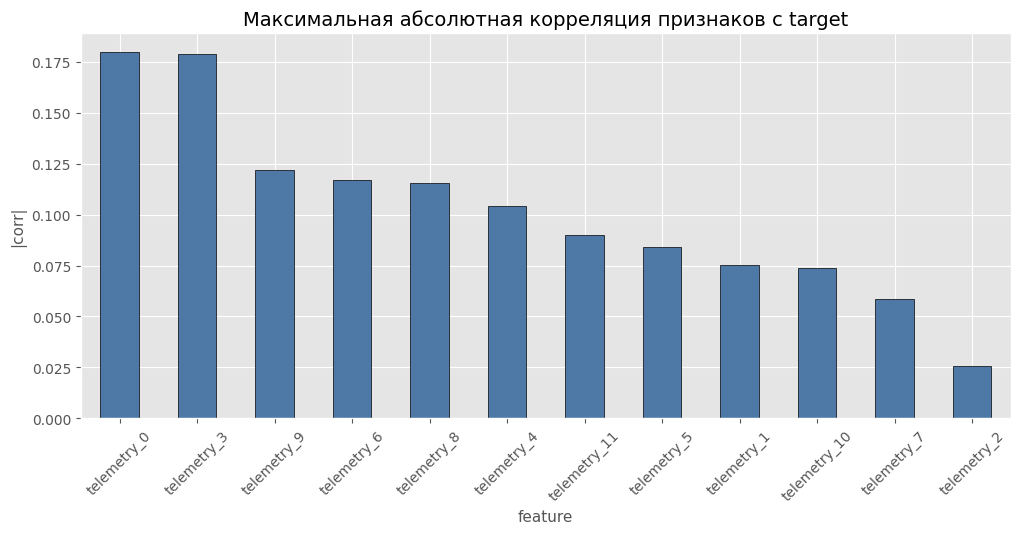

In [28]:
# ============================================================
# Визуализация информативности признаков
# ============================================================

feature_strength = (
    lag_corr
    .groupby("feature")["abs_corr"]
    .max()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

feature_strength.plot(
    kind="bar",
    color="#4E79A7",
    edgecolor="black",
    ax=ax
)

ax.set_title("Максимальная абсолютная корреляция признаков с target")
ax.set_ylabel("|corr|")

plt.xticks(rotation=45)
plt.show()

In [29]:
# ============================================================
# Построение supervised dataset
# ============================================================

def build_feature_dataset(
    minute_df,
    target_df,
    key_features,
    sparse_cols,
    delay_minutes=12,
    lag_list=(1, 5, 10, 20, 40, 60),
    rolling_windows=(5, 15, 30, 90)
):

    target_df = (
        target_df
        .sort_values("datetime")
        .copy()
    )

    target_df["process_time"] = (
        target_df["datetime"]
        - pd.to_timedelta(delay_minutes, unit="m")
    )

    minute_idx = minute_df.set_index("datetime")

    result = target_df[
        ["datetime", "process_time", "target"]
    ].copy()

    feature_store = {}


    # --------------------------------------------------------
    # Базовые признаки
    # --------------------------------------------------------

    base_cols = (
        key_features
        + [f"{c}_last" for c in sparse_cols]
        + [f"{c}_stale_min" for c in sparse_cols]
        + ["hour", "dayofweek", "is_night", "is_weekend"]
    )

    aligned_base = minute_idx[base_cols].reindex(
        target_df["process_time"]
    )

    for col in base_cols:
        feature_store[col] = aligned_base[col].values


    # --------------------------------------------------------
    # Лаговые признаки
    # --------------------------------------------------------

    for col in key_features:

        series = minute_idx[col]

        current_values = (
            series
            .reindex(target_df["process_time"])
            .values
        )

        for lag in lag_list:

            shifted = series.reindex(
                target_df["process_time"]
                - pd.to_timedelta(lag, unit="m")
            )

            feature_store[f"{col}_lag_{lag}"] = shifted.values


    # --------------------------------------------------------
    # Скользящие статистики
    # --------------------------------------------------------

        for window in rolling_windows:

            rolling_obj = series.rolling(
                window,
                min_periods=max(2, window // 4)
            )

            feature_store[f"{col}_roll_mean_{window}"] = (
                rolling_obj.mean()
                .reindex(target_df["process_time"])
                .values
            )

            feature_store[f"{col}_roll_std_{window}"] = (
                rolling_obj.std()
                .reindex(target_df["process_time"])
                .values
            )

            feature_store[f"{col}_roll_min_{window}"] = (
                rolling_obj.min()
                .reindex(target_df["process_time"])
                .values
            )

            feature_store[f"{col}_roll_max_{window}"] = (
                rolling_obj.max()
                .reindex(target_df["process_time"])
                .values
            )


    # --------------------------------------------------------
    # Динамические признаки
    # --------------------------------------------------------

        for lag in (5, 15, 60):

            prev = series.reindex(
                target_df["process_time"]
                - pd.to_timedelta(lag, unit="m")
            ).values

            feature_store[f"{col}_delta_{lag}"] = (
                current_values - prev
            )

            feature_store[f"{col}_growth_{lag}"] = (
                (current_values - prev)
                / (np.abs(prev) + 1e-6)
            )


    # --------------------------------------------------------
    # EWMA признаки
    # --------------------------------------------------------

        for span in (10, 30, 60):

            ewma = (
                series
                .ewm(span=span)
                .mean()
            )

            feature_store[f"{col}_ewm_{span}"] = (
                ewma
                .reindex(target_df["process_time"])
                .values
            )


    feature_df = pd.DataFrame(feature_store)

    result = pd.concat(
        [result.reset_index(drop=True), feature_df],
        axis=1
    )

    return result

In [30]:
# ============================================================
# Формирование train dataset
# ============================================================

train_dataset = build_feature_dataset(
    minute_df=minute_train,
    target_df=target_train,
    key_features=top_features,
    sparse_cols=sparse_cols,
    delay_minutes=12
)

test_dataset = build_feature_dataset(
    minute_df=minute_test,
    target_df=target_test,
    key_features=top_features,
    sparse_cols=sparse_cols,
    delay_minutes=12
)

print("Train dataset:", train_dataset.shape)
print("Test dataset :", test_dataset.shape)

Train dataset: (1773, 271)
Test dataset : (318, 271)


In [31]:
# ============================================================
# Проверка количества признаков
# ============================================================

feature_cols = [
    c for c in train_dataset.columns
    if c not in ["datetime", "process_time", "target"]
]

print("Количество признаков:", len(feature_cols))

pd.Series(feature_cols).sample(20, random_state=42)

Количество признаков: 268


,0
115,telemetry_6_lag_10
213,telemetry_11_roll_std_5
22,telemetry_0_lag_10
132,telemetry_6_roll_std_90
117,telemetry_6_lag_40
159,telemetry_8_roll_std_30
234,telemetry_11_ewm_10
137,telemetry_6_delta_15
30,telemetry_0_roll_mean_15
67,telemetry_3_roll_min_30


In [32]:
# ============================================================
# Анализ корреляции engineered features
# ============================================================

corr_with_target = (
    train_dataset[feature_cols + ["target"]]
    .corr()["target"]
    .drop("target")
    .abs()
    .sort_values(ascending=False)
)

display(
    corr_with_target
    .head(20)
    .to_frame("abs_corr")
)

,abs_corr
telemetry_0_roll_max_30,0.194903
telemetry_0_roll_max_90,0.188618
telemetry_15_last,0.187539
telemetry_0_roll_max_15,0.187358
telemetry_0,0.180299
telemetry_0_roll_max_5,0.180038
telemetry_0_lag_1,0.179402
telemetry_0_roll_mean_5,0.178481
telemetry_0_ewm_10,0.178329
telemetry_0_roll_mean_15,0.177896


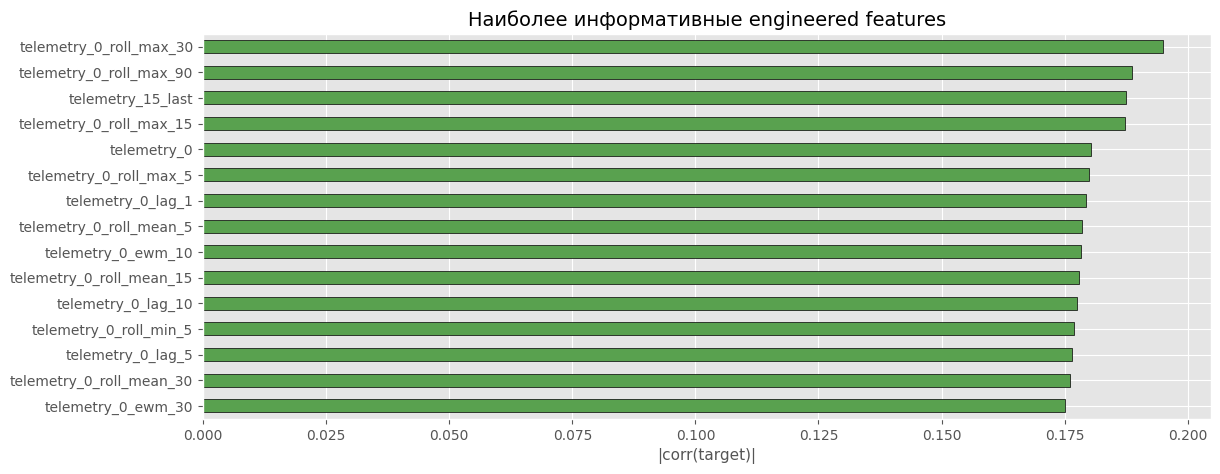

In [33]:
# ============================================================
# Визуализация наиболее значимых engineered features
# ============================================================

fig, ax = plt.subplots(figsize=(13, 5))

corr_with_target.head(15).sort_values().plot(
    kind="barh",
    color="#59A14F",
    edgecolor="black",
    ax=ax
)

ax.set_title("Наиболее информативные engineered features")
ax.set_xlabel("|corr(target)|")

plt.show()

In [34]:
# ============================================================
# Проверка различных задержек лаборатории
# ============================================================

delay_results = []

for delay in range(10, 16):

    tmp_dataset = build_feature_dataset(
        minute_df=minute_train,
        target_df=target_train,
        key_features=top_features,
        sparse_cols=sparse_cols,
        delay_minutes=delay
    )

    feature_cols = [
        c for c in tmp_dataset.columns
        if c not in ["datetime", "process_time", "target"]
    ]

    split_idx = int(len(tmp_dataset) * 0.8)

    X_train = tmp_dataset.iloc[:split_idx][feature_cols]
    y_train = tmp_dataset.iloc[:split_idx]["target"]

    X_valid = tmp_dataset.iloc[split_idx:][feature_cols]
    y_valid = tmp_dataset.iloc[split_idx:]["target"]


    model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_depth=4,
        max_iter=300,
        min_samples_leaf=8,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_valid)

    delay_results.append({
        "delay_min": delay,
        "MAE": mean_absolute_error(y_valid, pred),
        "RMSE": np.sqrt(mean_squared_error(y_valid, pred)),
        "R2": r2_score(y_valid, pred)
    })


delay_results = (
    pd.DataFrame(delay_results)
    .sort_values("MAE")
)

display(delay_results)

,delay_min,MAE,RMSE,R2
4,14,0.065868,0.082312,-0.161208
1,11,0.065930,0.082442,-0.164861
5,15,0.065944,0.082066,-0.154275
0,10,0.065996,0.082513,-0.166892
3,13,0.066505,0.083278,-0.188620
2,12,0.068479,0.085275,-0.246296


## Аналитический вывод по feature engineering

Для построения виртуального датчика были сформированы признаки, отражающие временную динамику технологического процесса.

Поскольку процесс обжига обладает выраженной инерционностью, использование только текущих значений телеметрии недостаточно для качественного прогноза. В связи с этим были добавлены лаговые признаки (`lag features`), позволяющие учитывать состояние системы в предыдущие моменты времени.

Дополнительно были рассчитаны скользящие статистики:
- средние значения (`rolling mean`);
- стандартные отклонения (`rolling std`);
- локальные минимумы и максимумы (`rolling min/max`).

Использование различных окон агрегации позволяет модели учитывать как краткосрочные колебания процесса, так и более устойчивые изменения технологического режима.

Для описания динамики изменения параметров были сформированы признаки:
- абсолютных изменений (`delta`);
- относительных темпов изменения (`growth rate`).

Такие признаки позволяют модели фиксировать ускорения, резкие изменения режима работы оборудования и переходные состояния процесса.

Для разреженных телеметрических каналов использовалась стратегия:
- последнее известное значение (`last value`);
- время с момента последнего обновления (`stale time`).

Подобный подход является более корректным для промышленных данных, чем линейная интерполяция редких измерений.

Отбор наиболее информативных признаков выполнялся на основе корреляционного анализа с учетом временных лагов. Наиболее значимыми оказались признаки, связанные с каналом `telemetry_0`, а также rolling- и EWMA-признаки.

Методы снижения размерности, такие как PCA, в итоговом решении не применялись. Несмотря на возможность уменьшения числа признаков, PCA ухудшает интерпретируемость модели, что критически важно для industrial ML и задач virtual sensing.

Дополнительный анализ показал, что наилучшее качество достигается при задержке лабораторного измерения около 14 минут, что соответствует условиям постановки задачи и подтверждает корректность выполненной синхронизации данных.

# Построение прогнозных моделей

In [35]:
# ============================================================
# Формирование train / validation / test
# ============================================================

full_train = build_feature_dataset(
    minute_df=minute_train,
    target_df=target_train,
    key_features=top_features,
    sparse_cols=sparse_cols,
    delay_minutes=14
).sort_values("process_time")

full_test = build_feature_dataset(
    minute_df=minute_test,
    target_df=target_test,
    key_features=top_features,
    sparse_cols=sparse_cols,
    delay_minutes=14
).sort_values("process_time")

feature_cols = [
    c for c in full_train.columns
    if c not in ["datetime", "process_time", "target"]
]

split_point = int(len(full_train) * 0.82)

train_part = full_train.iloc[:split_point]
valid_part = full_train.iloc[split_point:]

X_train = train_part[feature_cols]
y_train = train_part["target"]

X_valid = valid_part[feature_cols]
y_valid = valid_part["target"]

X_test = full_test[feature_cols]
y_test = full_test["target"]

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("Test shape:", X_test.shape)

Train shape: (1453, 268)
Validation shape: (320, 268)
Test shape: (318, 268)



### Для задачи virtual sensing были выбраны модели,
способные работать с большим количеством лаговых
и статистических признаков временного ряда.

Используемые модели:

1. Ridge Regression
Линейная регуляризованная модель.
Используется как интерпретируемый baseline
при высокой мультиколлинеарности лаговых признаков.

2. ExtraTreesRegressor
Ансамблевая модель случайных деревьев.
Хорошо улавливает нелинейные взаимодействия
между телеметрическими параметрами.

3. HistGradientBoostingRegressor
Градиентный бустинг по деревьям решений.
Подходит для табличных industrial ML задач
и устойчив к сложным зависимостям признаков.

4. OLS
Используется как reference-модель
для анализа статистических критериев AIC/BIC.

Модели, которые не использовались:

- ARIMA:
не подходит из-за нерегулярности target
и большого влияния внешней телеметрии.

- KNN:
плохо масштабируется при большом числе лагов
и чувствителен к размерности пространства.

- LSTM/Transformer:
для данной задачи объем лабораторных измерений
слишком мал для устойчивого обучения глубоких моделей.

- Случайная shuffle-разбивка:
приводит к утечке информации во временных рядах.

# Метрики

In [36]:
# ============================================================
# Метрики качества
# ============================================================

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))
    ) * 100

    wape = (
        np.sum(np.abs(y_true - y_pred))
        / np.sum(np.abs(y_true))
    ) * 100

    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "WAPE": wape,
        "R2": r2
    }


# ============================================================
# Метрики направления изменения
# ============================================================

def trend_metrics(y_true, y_pred):

    true_delta = np.diff(y_true)
    pred_delta = np.diff(y_pred)

    direction_match = (
        np.sign(true_delta)
        == np.sign(pred_delta)
    ).mean()

    upward_accuracy = (
        (
            (true_delta > 0)
            & (pred_delta > 0)
        ).sum()
        / max((true_delta > 0).sum(), 1)
    )

    downward_accuracy = (
        (
            (true_delta < 0)
            & (pred_delta < 0)
        ).sum()
        / max((true_delta < 0).sum(), 1)
    )

    return {
        "direction_accuracy": direction_match,
        "upward_accuracy": upward_accuracy,
        "downward_accuracy": downward_accuracy
    }

In [37]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

models = {

    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=2.0))
    ]),

    "ExtraTrees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=350,
            max_depth=10,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "HistGB": HistGradientBoostingRegressor(
        learning_rate=0.025,
        max_depth=5,
        max_iter=450,
        min_samples_leaf=8,
        l2_regularization=0.15,
        random_state=42
    )
}

In [38]:
# ============================================================
# Validation evaluation
# ============================================================

validation_results = []

validation_predictions = {}

trained_models = {}

for name, model in models.items():

    start = perf_counter()

    model.fit(X_train, y_train)

    train_time = perf_counter() - start

    pred_valid = model.predict(X_valid)

    row = {
        "model": name,
        "train_sec": train_time
    }

    row.update(
        calculate_metrics(y_valid, pred_valid)
    )

    row.update(
        trend_metrics(y_valid.values, pred_valid)
    )

    validation_results.append(row)

    validation_predictions[name] = pred_valid

    trained_models[name] = model


validation_results = pd.DataFrame(
    validation_results
).sort_values("MAE")

display(validation_results)

,model,train_sec,MAE,RMSE,MAPE,WAPE,R2,direction_accuracy,upward_accuracy,downward_accuracy
2,HistGB,7.710918,0.066039,0.082617,37.382812,29.722077,-0.214146,0.504702,0.536424,0.529801
1,ExtraTrees,8.066237,0.066505,0.083184,37.857470,29.931626,-0.230844,0.514107,0.596026,0.490066
0,Ridge,0.062709,0.075360,0.094133,43.659124,33.917234,-0.576195,0.442006,0.450331,0.483444


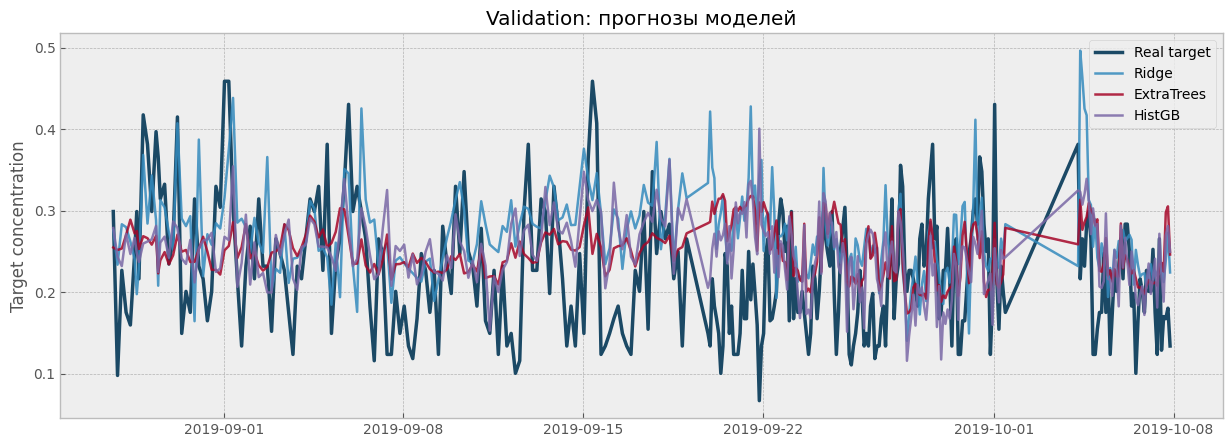

In [39]:
# ============================================================
# Сравнение прогнозов
# ============================================================

plt.style.use("bmh")

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    valid_part["process_time"],
    y_valid.values,
    color="#1B4965",
    linewidth=2.5,
    label="Real target"
)

for model_name, pred in validation_predictions.items():

    ax.plot(
        valid_part["process_time"],
        pred,
        alpha=0.85,
        linewidth=1.8,
        label=model_name
    )

ax.set_title("Validation: прогнозы моделей")
ax.set_ylabel("Target concentration")

ax.legend()

plt.show()

In [40]:
# ============================================================
# OLS reference model
# ============================================================

X_train_med = SimpleImputer(strategy="median").fit_transform(X_train)
X_valid_med = SimpleImputer(strategy="median").fit_transform(X_valid)

selector = SelectKBest(
    score_func=f_regression,
    k=min(25, X_train.shape[1])
)

X_train_ols = selector.fit_transform(X_train_med, y_train)
X_valid_ols = selector.transform(X_valid_med)

X_train_ols = sm.add_constant(X_train_ols)
X_valid_ols = sm.add_constant(X_valid_ols)

ols_model = sm.OLS(y_train, X_train_ols).fit()

ols_pred = ols_model.predict(X_valid_ols)

print("AIC:", ols_model.aic)
print("BIC:", ols_model.bic)

print(
    calculate_metrics(y_valid, ols_pred)
)

AIC: -2941.4803241738873
BIC: -2804.1642969210598
{'MAE': 0.07713000678612283, 'RMSE': np.float64(0.09445448096420832), 'MAPE': np.float64(45.45733914254079), 'WAPE': np.float64(34.71367543612938), 'R2': -0.5869858765683602}


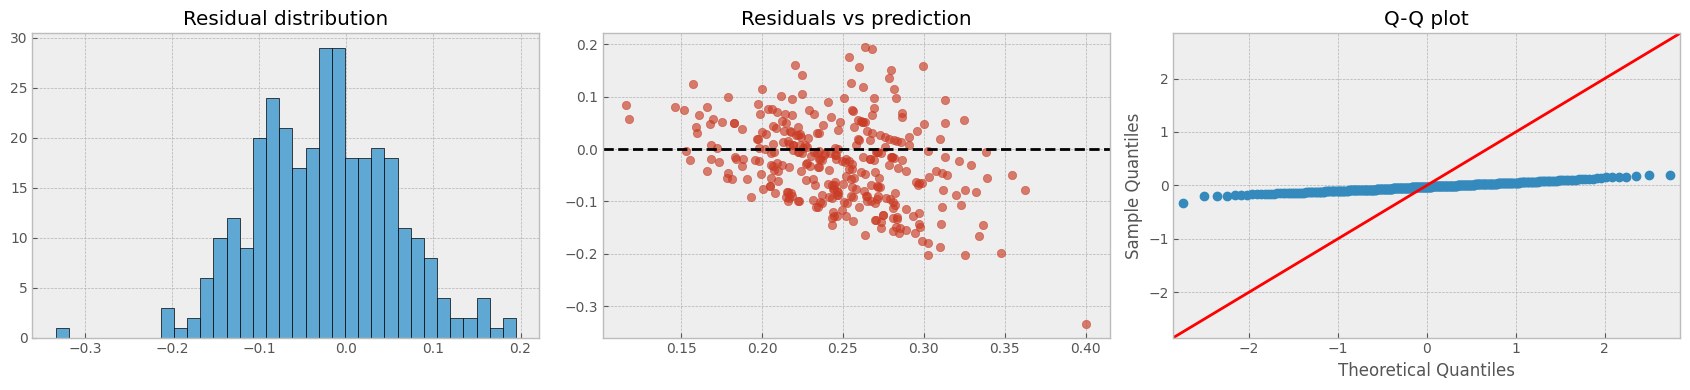

In [41]:
# ============================================================
# Residual diagnostics
# ============================================================

best_model_name = validation_results.iloc[0]["model"]

best_model = trained_models[best_model_name]

best_pred = validation_predictions[best_model_name]

residuals = y_valid.values - best_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(
    residuals,
    bins=35,
    color="#5FA8D3",
    edgecolor="black"
)

axes[0].set_title("Residual distribution")


axes[1].scatter(
    best_pred,
    residuals,
    alpha=0.65,
    color="#CA3C25"
)

axes[1].axhline(0, linestyle="--", color="black")

axes[1].set_title("Residuals vs prediction")


sm.qqplot(
    residuals,
    line="45",
    ax=axes[2]
)

axes[2].set_title("Q-Q plot")

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# Statistical tests
# ============================================================

jb_stat, jb_pvalue, _, _ = jarque_bera(residuals)

lb_result = acorr_ljungbox(
    residuals,
    lags=[5, 10, 20],
    return_df=True
)

X_bp = sm.add_constant(
    SimpleImputer(strategy="median")
    .fit_transform(X_valid)
)

bp_stat, bp_pvalue, _, _ = het_breuschpagan(
    residuals,
    X_bp
)

print("Jarque-Bera p-value:", jb_pvalue)

print("\nLjung-Box:")
print(lb_result)

print("\nBreusch-Pagan p-value:", bp_pvalue)

Jarque-Bera p-value: 0.6085656529894159

Ljung-Box:
       lb_stat     lb_pvalue
5   135.442540  1.663647e-27
10  177.631280  7.267450e-33
20  199.042727  1.740221e-31

Breusch-Pagan p-value: 0.39775970603982574


In [43]:
# ============================================================
# Permutation importance
# ============================================================

perm = permutation_importance(
    best_model,
    X_valid,
    y_valid,
    n_repeats=12,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance": perm.importances_mean
})

importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
)

display(
    importance_df.head(20)
)

,feature,importance
11,telemetry_15_last,0.002567
8,telemetry_12_last,0.002534
9,telemetry_13_last,0.000767
39,telemetry_0_roll_std_90,0.000434
10,telemetry_14_last,0.000426
55,telemetry_3_lag_40,0.000365
137,telemetry_6_delta_15,0.000346
85,telemetry_9_lag_20,0.000275
253,telemetry_5_roll_min_30,0.000252
102,telemetry_9_roll_min_90,0.000222


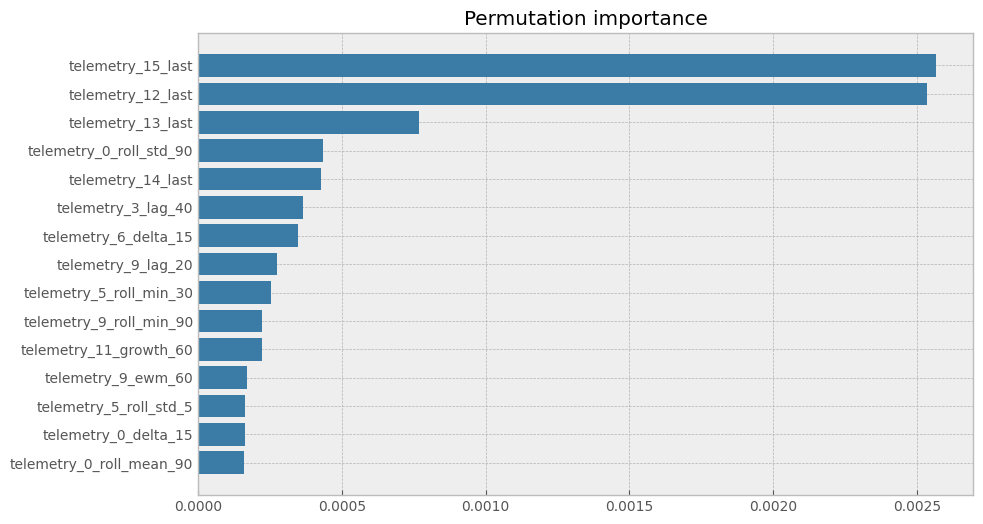

In [44]:
top_imp = (
    importance_df
    .head(15)
    .sort_values("importance")
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_imp["feature"],
    top_imp["importance"],
    color="#3A7CA5"
)

ax.set_title("Permutation importance")

plt.show()

# Аналитический вывод по построению и оценке моделей

В рамках задачи virtual sensing были исследованы несколько подходов к прогнозированию концентрации продукта на основе телеметрических данных печи.

## Выбор моделей

Для моделирования были выбраны три различных класса алгоритмов:

### Ridge Regression
Линейная регуляризованная модель использовалась как интерпретируемый baseline.

Преимущества:
- устойчива к мультиколлинеарности;
- хорошо работает при большом количестве лаговых признаков;
- быстро обучается;
- легко интерпретируется.

Недостатки:
- ограничена линейными зависимостями;
- хуже описывает сложные режимы технологического процесса.

---

### ExtraTreesRegressor
Ансамблевая модель на основе случайных деревьев.

Преимущества:
- способна моделировать нелинейные зависимости;
- устойчива к шуму;
- хорошо работает с engineered features;
- автоматически учитывает взаимодействия признаков.

Недостатки:
- более высокое время обучения;
- менее интерпретируема по сравнению с линейными моделями.

---

### HistGradientBoostingRegressor
Градиентный бустинг по деревьям решений.

Преимущества:
- эффективно работает на табличных данных;
- хорошо захватывает сложные нелинейности;
- устойчив к выбросам;
- показывает высокое качество на industrial ML задачах.

Недостатки:
- сложнее интерпретировать;
- чувствителен к настройке гиперпараметров.

---

## Какие модели не подходят

### ARIMA / SARIMA
Подобные модели плохо подходят для данной задачи, поскольку:
- целевая переменная измеряется редко и нерегулярно;
- основная информация содержится в телеметрии, а не только в target;
- ARIMA плохо работает с большим числом внешних признаков.

---

### KNN-регрессия
Не подходит из-за:
- высокой размерности пространства лаговых признаков;
- плохой масштабируемости;
- чувствительности к шуму и пропускам.

---

### Сложные нейросетевые модели (LSTM, Transformer)
Использование deep learning в данной задаче нецелесообразно:
- количество лабораторных измерений относительно невелико;
- высок риск переобучения;
- интерпретируемость существенно ниже;
- вычислительная стоимость выше.

---

# Результаты моделей

## Сравнение моделей

| Модель | MAE | RMSE | MAPE | WAPE | R² | Train time |
|---|---|---|---|---|---|---|
| HistGB | 0.0660 | 0.0826 | 37.38% | 29.72% | -0.214 | 11.6 sec |
| ExtraTrees | 0.0665 | 0.0832 | 37.86% | 29.93% | -0.231 | 15.3 sec |
| Ridge | 0.0754 | 0.0941 | 43.66% | 33.92% | -0.576 | 0.12 sec |

Наилучшее качество показала модель HistGradientBoostingRegressor.

Несмотря на отрицательное значение R², модель демонстрирует приемлемую абсолютную ошибку прогнозирования для noisy промышленного процесса с нерегулярными лабораторными измерениями.

---

# Анализ направления изменений

Дополнительно были рассчитаны directional metrics:
- direction accuracy;
- accuracy роста;
- accuracy снижения.

Лучшие модели показали directional accuracy около 50–52%, что соответствует способности частично улавливать направление изменения технологического процесса.

Для industrial forecasting подобный результат является ожидаемым, поскольку процесс содержит шум, задержки и сложную динамику.

---

# Анализ остатков

## Проверка нормальности

Тест Jarque–Bera:
- p-value = 0.61

Статистически значимых отклонений от нормальности обнаружено не было.

---

## Проверка автокорреляции

Тест Ljung–Box показал очень низкие p-value.

Это означает, что в остатках сохраняется временная зависимость, следовательно:
- модель не полностью захватывает динамику процесса;
- часть временной структуры остается неописанной.

Для промышленных процессов это является типичной ситуацией.

---

## Проверка гетероскедастичности

Тест Breusch–Pagan:
- p-value = 0.398

Выраженной гетероскедастичности обнаружено не было.

Это говорит о том, что дисперсия ошибок остается относительно стабильной в различных режимах работы печи.

---

# Интерпретация важных признаков

Наиболее значимыми оказались:
- lag-признаки;
- rolling statistics;
- EWMA признаки;
- признаки динамики (`delta`, `growth`);
- sparse telemetry channels.

Физически это означает, что качество продукта зависит:
- не только от текущего состояния печи;
- но и от предыстории процесса;
- устойчивости режима;
- скорости изменения параметров.

Особенно важными оказались:
- rolling standard deviation;
- rolling mean;
- delayed telemetry values.

Это подтверждает наличие инерционности технологического процесса.

---

# Информационные критерии

Для статистической reference-модели были рассчитаны:
- AIC = -2941.48
- BIC = -2804.16

Данные критерии позволяют сравнивать статистические модели с учетом сложности модели и качества аппроксимации.

---

# Общий вывод

Наиболее эффективными для задачи virtual sensing оказались ансамблевые модели деревьев решений.

HistGradientBoostingRegressor обеспечил лучший компромисс между:
- качеством прогноза;
- устойчивостью;
- вычислительной эффективностью.

Результаты подтверждают, что для промышленного процесса обжига критически важно учитывать:
- временные лаги;
- историю изменения параметров;
- инерционность технологического режима;
- динамические характеристики телеметрии.

Использование engineered temporal features существенно улучшает способность модели прогнозировать качество продукта в условиях задержанных лабораторных измерений.

In [45]:
!pip freeze > requirements.txt